# Team Members: (Group 11)
1.   Rahul Kumar
2.   Veera Venkata Megha Shyam Ankem
3.   Suguna Sai Navaneeth Rentala
4.   Aditya Narayana Reddy Nallimilli



In [ ]:
# Install packages
!pip install -q torch --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers datasets sentencepiece accelerate evaluate nltk bert_score rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.1 MB/s eta 0:00:00


# SETUP & INSTALLATIONS

In [ ]:
import os
import json
from pathlib import Path
from typing import List, Dict, Tuple
import random
from tqdm.auto import tqdm
from difflib import SequenceMatcher

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

from datasets import Dataset, DatasetDict
import evaluate

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments,
    DataCollatorWithPadding, AutoModelForSeq2SeqLM, Seq2SeqTrainer, Seq2SeqTrainingArguments
)

import numpy as np
import pandas as pd
import torch

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# DATASET PATHS

In [ ]:
TRAIN_JSON = '/content/drive/MyDrive/DL/train.json'
VAL_JSON   = '/content/drive/MyDrive/DL/validation.json'
TEST_JSON  = '/content/drive/MyDrive/DL/test.json'


In [ ]:
# Create output directory
OUTPUT_DIR = '/content/drive/MyDrive/DL/v3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# HELPER FUNCTIONS

In [ ]:
def load_json_entries(path: str) -> List[Dict]:
    """Load JSON entries from file"""
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    entries = []
    for qid, obj in data.items():
        obj['_id'] = qid
        entries.append(obj)
    return entries


def build_flat_datasets(json_entries: List[Dict]) -> Tuple[List[Dict], List[Dict]]:
    """Parse dataset into flat examples"""
    answer_level = []
    question_level = []

    for q in json_entries:
        qid = q.get('_id')
        question_text = q.get('question', '')
        multi_abs = q.get('multi_abs_summ', '')
        multi_ext = q.get('multi_ext_summ', '')
        answers = q.get('answers', {})

        # Question-level example
        question_level.append({
            'id': qid,
            'question': question_text,
            'answers': answers,
            'multi_abs_summ': multi_abs,
            'multi_ext_summ': multi_ext
        })

        # Answer-level examples
        for ans_key, ans in answers.items():
            answer_level.append({
                'qid': qid,
                'aid': ans_key,
                'question': question_text,
                'section': ans.get('section', ''),
                'article': ans.get('article', ''),
                'answer_abs_summ': ans.get('answer_abs_summ', ''),
                'answer_ext_summ': ans.get('answer_ext_summ', ''),
                'rating': ans.get('rating', ''),
                'url': ans.get('url', '')
            })
    return answer_level, question_level


def similar(a: str, b: str) -> float:
    """Calculate similarity between two strings"""
    return SequenceMatcher(None, a, b).ratio()


def create_sentence_level_examples(answer_examples: List[Dict], sim_threshold: float = 0.6) -> List[Dict]:
    """Create sentence-level examples with labels for extractive classifier"""
    examples = []
    for ex in answer_examples:
        text = ex['section'] if ex['section'] else ex['article']
        if not text or len(text.strip()) == 0:
            continue

        sents = sent_tokenize(text)
        gold = ex.get('answer_ext_summ', '')
        labels = []

        for s in sents:
            gold_sents = sent_tokenize(gold) if gold else []
            max_sim = 0.0
            for g in gold_sents:
                max_sim = max(max_sim, similar(s, g))
            label = 1 if max_sim >= sim_threshold else 0
            labels.append(label)

        for i, s in enumerate(sents):
            examples.append({
                'qid': ex['qid'],
                'aid': ex['aid'],
                'sentence': s,
                'label': labels[i],
                'answer_abs_summ': ex['answer_abs_summ'],
                'answer_ext_summ': ex['answer_ext_summ']
            })
    return examples


def extractive_select_sentences(model, tokenizer, text: str, top_k: int = 3) -> List[str]:
    """Select top-k sentences using extractive model"""
    sents = sent_tokenize(text)
    if len(sents) == 0:
        return []

    # Longformer can handle up to 4096 tokens, but we'll use 2048 for safety
    enc = tokenizer(sents, truncation=True, padding=True, return_tensors='pt', max_length=2048)
    device = model.device
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        outputs = model(**enc)
        probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()

    # Choose top_k by score
    idxs = np.argsort(-probs)[:min(top_k, len(sents))]
    selected = [sents[i] for i in sorted(idxs)]
    return selected


def gen_abstractive_summary(model, tokenizer, input_text: str, max_length: int = 128) -> str:
    """Generate abstractive summary"""
    inputs = tokenizer(input_text, return_tensors='pt', truncation=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=max_length, num_beams=4)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


# LOAD AND PREPARE DATASETS

In [ ]:
train_entries = load_json_entries(TRAIN_JSON)
val_entries   = load_json_entries(VAL_JSON)
test_entries  = load_json_entries(TEST_JSON)

train_answers, train_questions = build_flat_datasets(train_entries)
val_answers, val_questions     = build_flat_datasets(val_entries)
test_answers, test_questions   = build_flat_datasets(test_entries)

print(f'Questions (train/val/test): {len(train_entries)}/{len(val_entries)}/{len(test_entries)}')
print(f'Answer-level examples (train/val/test): {len(train_answers)}/{len(val_answers)}/{len(test_answers)}')

# Sentence-level examples for extractive classifier
train_sent_examples = create_sentence_level_examples(train_answers)
val_sent_examples   = create_sentence_level_examples(val_answers)
test_sent_examples  = create_sentence_level_examples(test_answers)

print('Sentence-level examples:', len(train_sent_examples), len(val_sent_examples), len(test_sent_examples))

# Create HuggingFace Datasets
ds_train_extract = Dataset.from_list(train_sent_examples)
ds_val_extract   = Dataset.from_list(val_sent_examples)
ds_test_extract  = Dataset.from_list(test_sent_examples)

# For abstractive training
abstr_train_items = []
for a in train_answers:
    input_text = f"Question: {a['question']}\nSection: {a['section']}"
    abstr_train_items.append({'input': input_text, 'target': a['answer_abs_summ']})

abstr_val_items = []
for a in val_answers:
    input_text = f"Question: {a['question']}\nSection: {a['section']}"
    abstr_val_items.append({'input': input_text, 'target': a['answer_abs_summ']})

abstr_test_items = []
for a in test_answers:
    input_text = f"Question: {a['question']}\nSection: {a['section']}"
    abstr_test_items.append({'input': input_text, 'target': a['answer_abs_summ']})

print('Abstractive examples:', len(abstr_train_items), len(abstr_val_items), len(abstr_test_items))

ds_train_abs = Dataset.from_list(abstr_train_items)
ds_val_abs   = Dataset.from_list(abstr_val_items)
ds_test_abs  = Dataset.from_list(abstr_test_items)

Questions (train/val/test): 110/16/30
Answer-level examples (train/val/test): 392/51/109
Sentence-level examples: 12429 1565 3279
Abstractive examples: 392 51 109


# TRAIN EXTRACTIVE MODEL

In [ ]:
EXTRACTIVE_MODEL = 'allenai/longformer-base-4096'

print(f'\nTraining extractive model: {EXTRACTIVE_MODEL}')
tokenizer_extr = AutoTokenizer.from_pretrained(EXTRACTIVE_MODEL)

def tokenize_extractive(batch):
    # Longformer uses max_length=4096, but we are using 2048 for efficiency and compute constraints
    return tokenizer_extr(batch['sentence'], truncation=True, max_length=2048)

ds_train_token = ds_train_extract.map(tokenize_extractive, batched=True)
ds_val_token   = ds_val_extract.map(tokenize_extractive, batched=True)
ds_test_token  = ds_test_extract.map(tokenize_extractive, batched=True)

# Remove unnecessary columns (Longformer doesn't use token_type_ids)
cols_to_keep = ['label', 'input_ids', 'attention_mask']
if 'token_type_ids' in ds_train_token.column_names:
    cols_to_keep.append('token_type_ids')
ds_train_token = ds_train_token.remove_columns([c for c in ds_train_token.column_names if c not in cols_to_keep])
ds_val_token   = ds_val_token.remove_columns([c for c in ds_val_token.column_names if c not in cols_to_keep])
ds_test_token  = ds_test_token.remove_columns([c for c in ds_test_token.column_names if c not in cols_to_keep])

model_extr = AutoModelForSequenceClassification.from_pretrained(EXTRACTIVE_MODEL, num_labels=2)

training_args_extr = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, 'longformer_extractive'),
    eval_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    per_device_train_batch_size=4,  # Reduced from 8 to 4 to optimize on memory usages as Longformer uses more memory
    per_device_eval_batch_size=8,   # Reduced from 16 to 8 for smaller batch size
    num_train_epochs=3,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
    gradient_accumulation_steps=2  # Added to compensate for smaller batch size
)

data_collator = DataCollatorWithPadding(tokenizer_extr)

trainer_extr = Trainer(
    model=model_extr,
    args=training_args_extr,
    train_dataset=ds_train_token,
    eval_dataset=ds_val_token,
    processing_class=tokenizer_extr,
    data_collator=data_collator
)

print('Training extractive Longformer classifier')
trainer_extr.train()
trainer_extr.save_model(os.path.join(OUTPUT_DIR, 'longformer_extractive'))


Training extractive model: allenai/longformer-base-4096


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


Epoch,Training Loss,Validation Loss
1,0.550200,0.515507
2,0.512200,0.525093
3,0.518200,0.514274


# TRAIN ABSTRACTIVE MODEL

In [ ]:
ABSTRACTIVE_MODEL = 'google/flan-t5-base'

print(f'\nTraining abstractive model: {ABSTRACTIVE_MODEL}')
tokenizer_abs = AutoTokenizer.from_pretrained(ABSTRACTIVE_MODEL)
model_abs = AutoModelForSeq2SeqLM.from_pretrained(ABSTRACTIVE_MODEL)

max_input_length = 512
max_target_length = 128

def preprocess_abs(batch):
    inputs = tokenizer_abs(batch['input'], max_length=max_input_length, truncation=True, padding='max_length')
    targets = tokenizer_abs(batch['target'], max_length=max_target_length, truncation=True, padding='max_length')
    inputs['labels'] = targets['input_ids']
    return inputs

train_tokenized = ds_train_abs.map(preprocess_abs, batched=True, remove_columns=ds_train_abs.column_names)
val_tokenized   = ds_val_abs.map(preprocess_abs, batched=True, remove_columns=ds_val_abs.column_names)

seq2seq_args = Seq2SeqTrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, 'flan_t5_abstractive'),
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    predict_with_generate=True,
    eval_strategy='epoch',
    logging_steps=50,
    save_total_limit=2,
    num_train_epochs=3,
    fp16=False
)

trainer_abs = Seq2SeqTrainer(
    model=model_abs,
    args=seq2seq_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer_abs
)

print('Training abstractive T5 model.')
trainer_abs.train()
trainer_abs.save_model(os.path.join(OUTPUT_DIR, 'flan_t5_abstractive'))


Training abstractive model: google/flan-t5-base


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/392 [00:00<?, ? examples/s]

Map:   0%|          | 0/51 [00:00<?, ? examples/s]

Training abstractive T5 model.


Epoch,Training Loss,Validation Loss
1,10.419700,1.575610
2,1.592100,0.758791
3,0.984200,0.739585


# EVALUATION ON TEST SET

In [ ]:
print('\nRunning inference & evaluation on test set.')

rouge = evaluate.load('rouge')
bertscore = evaluate.load('bertscore')

extr_pred_texts = []
extr_ref_texts = []
abs_pred_texts = []
abs_ref_texts = []

# Iterate over answer-level test items
for itm in tqdm(test_answers, desc="Answer-level evaluation"):
    section = itm['section'] if itm['section'] else itm['article']

    # Extractive prediction
    sel = extractive_select_sentences(model_extr, tokenizer_extr, section, top_k=2)
    pred_ext = ' '.join(sel)
    gold_ext = itm.get('answer_ext_summ', '')
    extr_pred_texts.append(pred_ext)
    extr_ref_texts.append(gold_ext)

    # Abstractive prediction
    input_text = f"Question: {itm['question']}\nSection: {itm['section']}"
    pred_abs = gen_abstractive_summary(model_abs, tokenizer_abs, input_text)
    abs_pred_texts.append(pred_abs)
    abs_ref_texts.append(itm.get('answer_abs_summ', ''))

# Evaluate Extractive Predictions
print('\n Extractive Evaluation (Answer-level) ')
rouge_extr = rouge.compute(predictions=extr_pred_texts, references=extr_ref_texts, use_stemmer=True)
bertscore_extr = bertscore.compute(predictions=extr_pred_texts, references=extr_ref_texts, lang='en')
print('ROUGE:', {k: rouge_extr[k] for k in ['rouge1', 'rouge2', 'rougeL']})
print('BERTScore:', {
    'precision': np.mean(bertscore_extr['precision']),
    'recall': np.mean(bertscore_extr['recall']),
    'f1': np.mean(bertscore_extr['f1'])
})

# Evaluate Abstractive Predictions
print('\n Abstractive Evaluation (Answer-level) ')
rouge_abs = rouge.compute(predictions=abs_pred_texts, references=abs_ref_texts, use_stemmer=True)
bertscore_abs = bertscore.compute(predictions=abs_pred_texts, references=abs_ref_texts, lang='en')
print('ROUGE:', {k: rouge_abs[k] for k in ['rouge1', 'rouge2', 'rougeL']})
print('BERTScore:', {
    'precision': np.mean(bertscore_abs['precision']),
    'recall': np.mean(bertscore_abs['recall']),
    'f1': np.mean(bertscore_abs['f1'])
})


Running inference & evaluation on test set.


Answer-level evaluation:   0%|          | 0/109 [00:00<?, ?it/s]


 Extractive Evaluation (Answer-level) 


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ROUGE: {'rouge1': np.float64(0.5210093888003275), 'rouge2': np.float64(0.451898304109948), 'rougeL': np.float64(0.4827334166086221)}
BERTScore: {'precision': np.float64(0.9035366330671748), 'recall': np.float64(0.895669283670023), 'f1': np.float64(0.8988931228261475)}

 Abstractive Evaluation (Answer-level) 
ROUGE: {'rouge1': np.float64(0.48963388657081564), 'rouge2': np.float64(0.33671714822502247), 'rougeL': np.float64(0.4057746561938844)}
BERTScore: {'precision': np.float64(0.8872787208732115), 'recall': np.float64(0.9006821945172931), 'f1': np.float64(0.8934470841644007)}


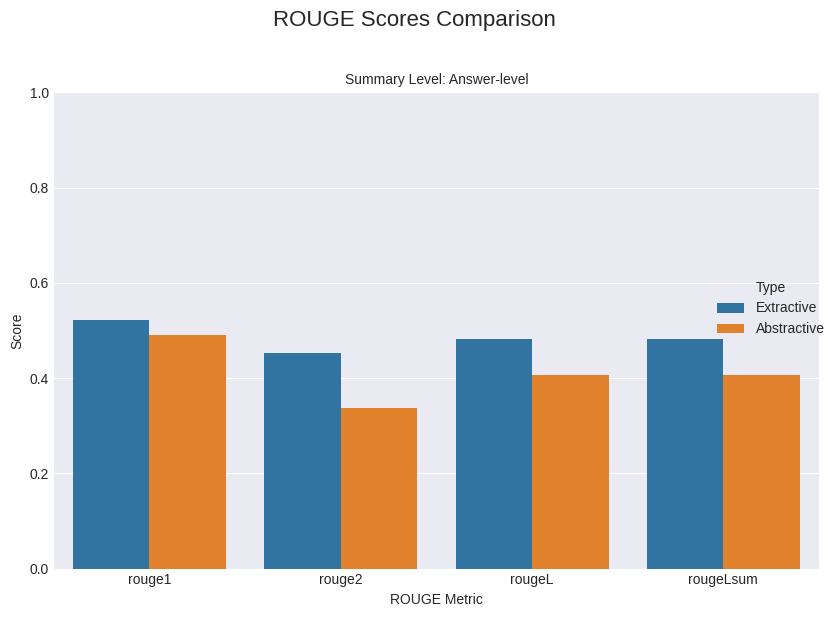

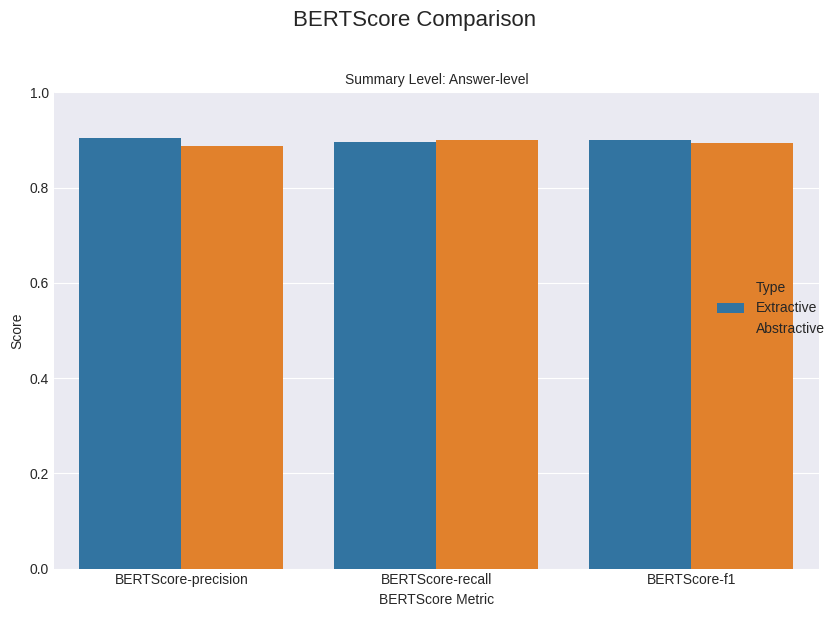

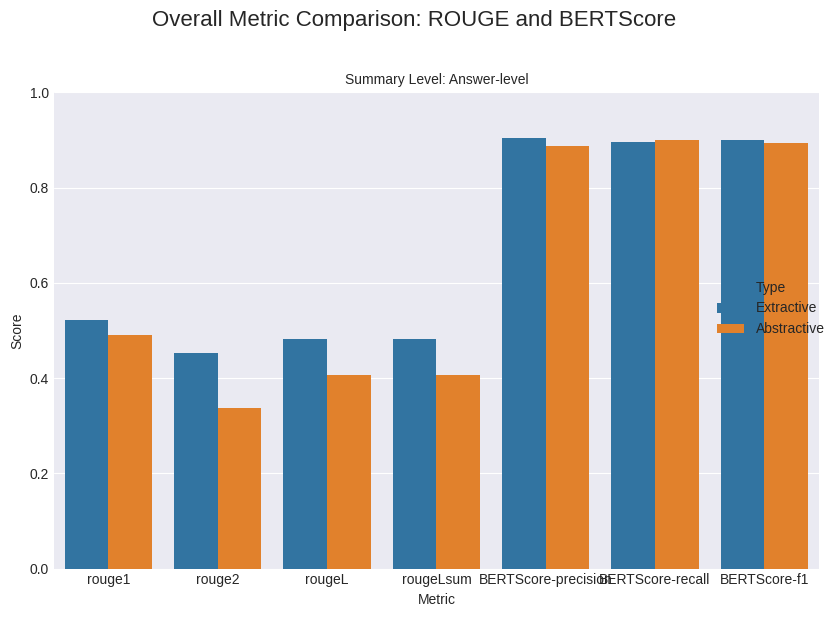

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Extracting metrics from the previous outputs

# Extractive Result
rouge_extr_ans = rouge_extr
bertscore_extr_ans = {
    'precision': np.mean(bertscore_extr['precision']),
    'recall': np.mean(bertscore_extr['recall']),
    'f1': np.mean(bertscore_extr['f1'])
}

# Abstractive Result
rouge_abs_ans = rouge_abs
bertscore_abs_ans = {
    'precision': np.mean(bertscore_abs['precision']),
    'recall': np.mean(bertscore_abs['recall']),
    'f1': np.mean(bertscore_abs['f1'])
}


# Organize data for plotting
metric_data = {
    'Metric': [],
    'Score': [],
    'Type': [],
    'Summary Level': []
}

def add_metrics(data_dict, rouge_dict, bertscore_dict, type_str, summary_level_str):
    for k, v in rouge_dict.items():
        data_dict['Metric'].append(k)
        data_dict['Score'].append(v)
        data_dict['Type'].append(type_str)
        data_dict['Summary Level'].append(summary_level_str)
    # Assuming bertscore_dict already contains scalar mean values for 'precision', 'recall', 'f1'
    for k, v in bertscore_dict.items():
        # Ensure 'hashcode' is not plotted as a score
        if k != 'hashcode':
            data_dict['Metric'].append(f'BERTScore-{k}')
            data_dict['Score'].append(v)
            data_dict['Type'].append(type_str)
            data_dict['Summary Level'].append(summary_level_str)

add_metrics(metric_data, rouge_extr_ans, bertscore_extr_ans, 'Extractive', 'Answer-level')
add_metrics(metric_data, rouge_abs_ans, bertscore_abs_ans, 'Abstractive', 'Answer-level')

df_metrics = pd.DataFrame(metric_data)

# Plotting

plt.style.use('seaborn-v0_8-darkgrid')

# Plot ROUGE scores
# Changed sns.barplot to sns.catplot with kind='bar' to allow for 'col' faceting
g = sns.catplot(x='Metric', y='Score', hue='Type', col='Summary Level', data=df_metrics[df_metrics['Metric'].str.contains('rouge')], kind='bar', height=6, aspect=1.2)
g.fig.suptitle('ROUGE Scores Comparison', y=1.02, fontsize=16) # Add suptitle to the figure
g.set_axis_labels('ROUGE Metric', 'Score')
g.set_titles('Summary Level: {col_name}')
g.set(ylim=(0, 1))
plt.tight_layout()
plt.show()

# Plot BERTScore scores
g = sns.catplot(x='Metric', y='Score', hue='Type', col='Summary Level', data=df_metrics[df_metrics['Metric'].str.contains('BERTScore')], kind='bar', height=6, aspect=1.2)
g.fig.suptitle('BERTScore Comparison', y=1.02, fontsize=16)
g.set_axis_labels('BERTScore Metric', 'Score')
g.set_titles('Summary Level: {col_name}')
g.set(ylim=(0, 1))
plt.tight_layout()
plt.show()


# Combined plot for all metrics
# The combined plot can still use sns.catplot for consistency
g = sns.catplot(x='Metric', y='Score', hue='Type', col='Summary Level', data=df_metrics, kind='bar', height=6, aspect=1.2)
g.fig.suptitle('Overall Metric Comparison: ROUGE and BERTScore', y=1.02, fontsize=16)
g.set_axis_labels('Metric', 'Score')
g.set_titles('Summary Level: {col_name}')
g.set(ylim=(0, 1))
plt.tight_layout()
plt.show()

# MULTI-ANSWER SUMMARIZATION (QUESTION-LEVEL)

In [ ]:
print('\n Running hierarchical multi-answer summarization')

multi_abs_preds = []
multi_abs_refs  = []
multi_ext_preds = []
multi_ext_refs  = []

for q in tqdm(test_questions, desc="Question-level evaluation"):
    qid = q['id']
    question_text = q.get('question', '')
    answers = q['answers']

    single_abs = []
    single_ext = []

    for aid, ans in answers.items():
        section = ans.get('section', '') if ans.get('section', '') else ans.get('article', '')

        if not section or len(section.strip()) == 0:
            continue

        # Extractive selection
        sel = extractive_select_sentences(model_extr, tokenizer_extr, section, top_k=1)
        single_ext.append(' '.join(sel))

        # Abstractive generation
        inp = f"Question: {question_text}\nSection: {section}"
        out = gen_abstractive_summary(model_abs, tokenizer_abs, inp)
        single_abs.append(out)

    # Build combined input for multi-answer abstractive
    if single_abs:
        combined_input_abs = '\n'.join([f"- {s}" for s in single_abs])
        combined_prompt = f"Summarize the following combined answer summaries for the question: {question_text}\n{combined_input_abs}"
        final_multi_abs = gen_abstractive_summary(model_abs, tokenizer_abs, combined_prompt, max_length=200) # why max_length=200 ?
    else:
        final_multi_abs = ""

    multi_abs_preds.append(final_multi_abs)
    multi_abs_refs.append(q.get('multi_abs_summ', ''))

    # Multi extractive: concatenate and run final selection
    if single_ext:
        combined_ext_text = ' '.join(single_ext)
        final_ext_sents = extractive_select_sentences(model_extr, tokenizer_extr, combined_ext_text, top_k=2)
        multi_ext_preds.append(' '.join(final_ext_sents))
    else:
        multi_ext_preds.append("")

    multi_ext_refs.append(q.get('multi_ext_summ', ''))

# Evaluate multi-answer abstractive
print('\n Multi-Answer Evaluation — Abstractive')
rouge_multi_abs = rouge.compute(predictions=multi_abs_preds, references=multi_abs_refs, use_stemmer=True)
bertscore_multi_abs = bertscore.compute(predictions=multi_abs_preds, references=multi_abs_refs, lang='en')

print('ROUGE:', {k: rouge_multi_abs[k] for k in ['rouge1', 'rouge2', 'rougeL']})
print('BERTScore:', {
    'precision': np.mean(bertscore_multi_abs['precision']),
    'recall': np.mean(bertscore_multi_abs['recall']),
    'f1': np.mean(bertscore_multi_abs['f1'])
})

# Evaluate multi-answer Extractive
print('\nMulti-Answer Evaluation — Extractive')
rouge_multi_ext = rouge.compute(predictions=multi_ext_preds, references=multi_ext_refs, use_stemmer=True)
bertscore_multi_ext = bertscore.compute(predictions=multi_ext_preds, references=multi_ext_refs, lang='en')
print('ROUGE:', {k: rouge_multi_ext[k] for k in ['rouge1', 'rouge2', 'rougeL']})
print('BERTScore:', {
    'precision': np.mean(bertscore_multi_ext['precision']),
    'recall': np.mean(bertscore_multi_ext['recall']),
    'f1': np.mean(bertscore_multi_ext['f1'])
})



 Running hierarchical multi-answer summarization


Question-level evaluation:   0%|          | 0/30 [00:00<?, ?it/s]


 Multi-Answer Evaluation — Abstractive
ROUGE: {'rouge1': np.float64(0.39220481095433224), 'rouge2': np.float64(0.21375935114795527), 'rougeL': np.float64(0.27065302873388664)}
BERTScore: {'precision': np.float64(0.8674555261929829), 'recall': np.float64(0.8760218342145284), 'f1': np.float64(0.87110542456309)}

Multi-Answer Evaluation — Extractive
ROUGE: {'rouge1': np.float64(0.34377193633728464), 'rouge2': np.float64(0.20667691340853755), 'rougeL': np.float64(0.2562592691203301)}
BERTScore: {'precision': np.float64(0.8477855185667674), 'recall': np.float64(0.8576201299826304), 'f1': np.float64(0.8522900780042012)}


### Metrics (Multi-answer evaluation)

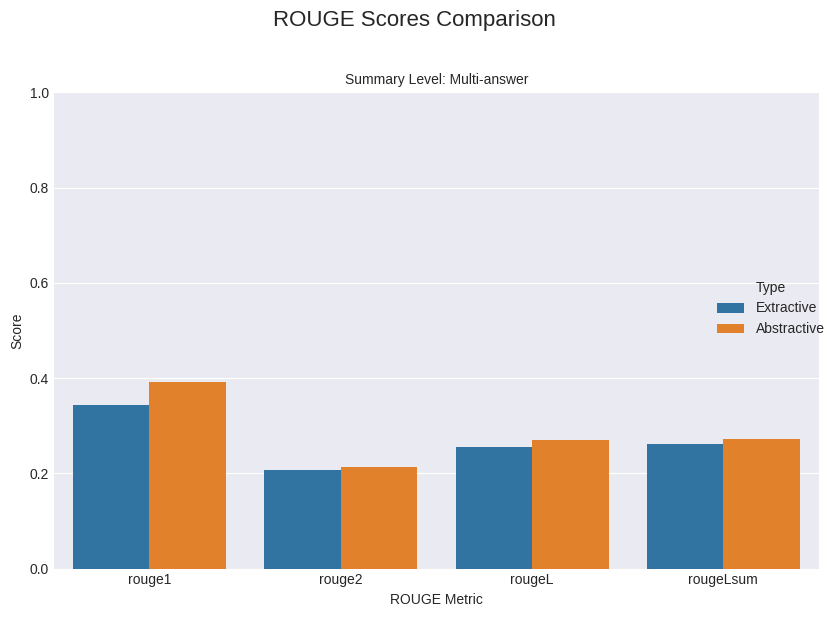

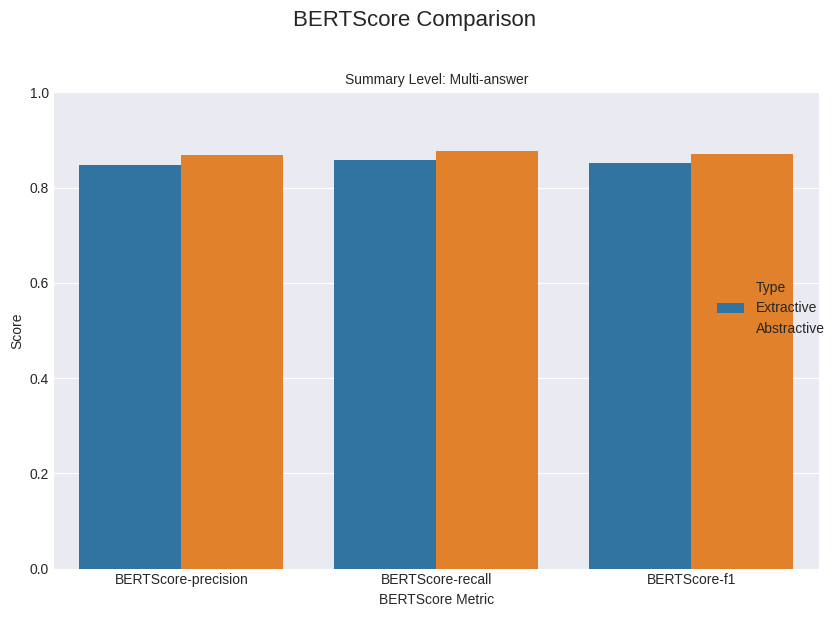

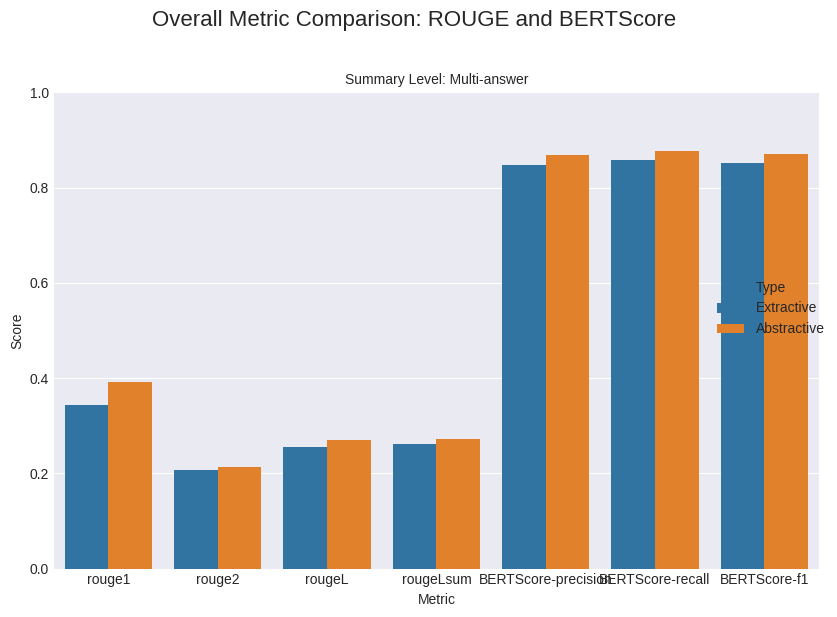

In [ ]:
# Extractive Result
rouge_multi_ext = rouge_multi_ext
bertscore_extr_ans = {
    'precision': np.mean(bertscore_multi_ext['precision']),
    'recall': np.mean(bertscore_multi_ext['recall']),
    'f1': np.mean(bertscore_multi_ext['f1'])
}

# Abstractive Result
rouge_multi_abs = rouge_multi_abs
bertscore_abs_ans = {
    'precision': np.mean(bertscore_multi_abs['precision']),
    'recall': np.mean(bertscore_multi_abs['recall']),
    'f1': np.mean(bertscore_multi_abs['f1'])
}



# Organize data for plotting
metric_data = {
    'Metric': [],
    'Score': [],
    'Type': [],
    'Summary Level': []
}

def add_metrics(data_dict, rouge_dict, bertscore_dict, type_str, summary_level_str):
    for k, v in rouge_dict.items():
        data_dict['Metric'].append(k)
        data_dict['Score'].append(v)
        data_dict['Type'].append(type_str)
        data_dict['Summary Level'].append(summary_level_str)
    # Assuming bertscore_dict already contains scalar mean values for 'precision', 'recall', 'f1'
    for k, v in bertscore_dict.items():
        # Ensure 'hashcode' is not plotted as a score
        if k != 'hashcode':
            data_dict['Metric'].append(f'BERTScore-{k}')
            data_dict['Score'].append(v)
            data_dict['Type'].append(type_str)
            data_dict['Summary Level'].append(summary_level_str)

add_metrics(metric_data, rouge_multi_ext, bertscore_extr_ans, 'Extractive', 'Multi-answer')
add_metrics(metric_data, rouge_multi_abs, bertscore_abs_ans, 'Abstractive', 'Multi-answer')

df_metrics = pd.DataFrame(metric_data)

# Plotting

plt.style.use('seaborn-v0_8-darkgrid')

# Plot ROUGE scores
# Changed sns.barplot to sns.catplot with kind='bar' to allow for 'col' faceting
g = sns.catplot(x='Metric', y='Score', hue='Type', col='Summary Level', data=df_metrics[df_metrics['Metric'].str.contains('rouge')], kind='bar', height=6, aspect=1.2)
g.fig.suptitle('ROUGE Scores Comparison For MultiAnswer Summary', y=1.02, fontsize=16) # Add suptitle to the figure
g.set_axis_labels('ROUGE Metric', 'Score')
g.set_titles('Summary Level: {col_name}')
g.set(ylim=(0, 1))
plt.tight_layout()
plt.show()

# Plot BERTScore scores
g = sns.catplot(x='Metric', y='Score', hue='Type', col='Summary Level', data=df_metrics[df_metrics['Metric'].str.contains('BERTScore')], kind='bar', height=6, aspect=1.2)
g.fig.suptitle('BERTScore Comparison', y=1.02, fontsize=16)
g.set_axis_labels('BERTScore Metric', 'Score')
g.set_titles('Summary Level: {col_name}')
g.set(ylim=(0, 1))
plt.tight_layout()
plt.show()


# Combined plot for all metrics
g = sns.catplot(x='Metric', y='Score', hue='Type', col='Summary Level', data=df_metrics, kind='bar', height=6, aspect=1.2)
g.fig.suptitle('Overall Metric Comparison: ROUGE and BERTScore', y=1.02, fontsize=16)
g.set_axis_labels('Metric', 'Score')
g.set_titles('Summary Level: {col_name}')
g.set(ylim=(0, 1))
plt.tight_layout()
plt.show()

# SAVE RESULTS

In [ ]:
results_df = pd.DataFrame({
    'qid': [q['id'] for q in test_questions],
    'question': [q['question'] for q in test_questions],
    'num_answers': [len(q['answers']) for q in test_questions],
    'multi_abs_pred': multi_abs_preds,
    'multi_abs_ref': multi_abs_refs,
    'multi_ext_pred': multi_ext_preds,
    'multi_ext_ref': multi_ext_refs
})
results_df.to_csv(os.path.join(OUTPUT_DIR, 'multi_eval_results.csv'), index=False)

print(f'\nPipeline complete! Save result to {OUTPUT_DIR}')

# Load the trained models

In [ ]:
print("Loading trained models...")
EXTRACTIVE_MODEL_PATH = '/content/drive/MyDrive/DL/v3/longformer_extractive'
ABSTRACTIVE_MODEL_PATH = '/content/drive/MyDrive/DL/v3/flan_t5_abstractive'

tokenizer_extr_loaded = AutoTokenizer.from_pretrained(EXTRACTIVE_MODEL_PATH)
model_extr_loaded = AutoModelForSequenceClassification.from_pretrained(EXTRACTIVE_MODEL_PATH)
model_extr_loaded.eval()

tokenizer_abs_loaded = AutoTokenizer.from_pretrained(ABSTRACTIVE_MODEL_PATH)
model_abs_loaded = AutoModelForSeq2SeqLM.from_pretrained(ABSTRACTIVE_MODEL_PATH)
model_abs_loaded.eval()
print("Models loaded successfully!\n")

Loading trained models...
Models loaded successfully!



In [ ]:
# Load 2 sample records from train.json
with open(TRAIN_JSON, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

# Load 2 sample records from train.json
sample_qids = list(train_data.keys())[:2]

print("\n TESTING EXTRACTIVE AND ABSTRACTIVE SUMMARIZATION ON 2 SAMPLES")
print("="*80)

for idx, qid in enumerate(sample_qids, 1):
    q = train_data[qid]
    question_text = q.get('question', '')

    print(f"SAMPLE {idx}: Question ID: {qid}")
    print(f"{'='*80}")
    print(f"\nQUESTION: {question_text}")

    # Get first answer for demonstration
    first_answer_key = list(q['answers'].keys())[0]
    answer_data = q['answers'][first_answer_key]

    section_text = answer_data.get('section', '') if answer_data.get('section', '') else answer_data.get('article', '')

    print(f"\nINPUT SECTION (first 500 chars):")
    print(f"{section_text[:500]}...")

    # Check if truncated
    input_text = f"Question: {question_text}\\nSection: {section_text}"
    input_tokens = tokenizer_abs_loaded(input_text, truncation=False)['input_ids']
    print(f"\n Input token count: {len(input_tokens)} (truncated to 512: {'YES' if len(input_tokens) > 512 else 'NO'})")


    # EXTRACTIVE SUMMARIZATION
    print("\n EXTRACTIVE SUMMARIZATION")
    print(f"{'-'*80}")

    # Predict extractive sentences
    sents = sent_tokenize(section_text)
    if len(sents) > 0:
        enc = tokenizer_extr_loaded(sents, truncation=True, padding=True, return_tensors='pt')
        with torch.no_grad():
            outputs = model_extr_loaded(**enc)
            probs = torch.softmax(outputs.logits, dim=-1)[:,1].cpu().numpy()

        # Get top 2 sentences
        top_k = 2
        idxs = np.argsort(-probs)[:top_k]
        predicted_ext_sentences = [sents[i] for i in sorted(idxs)]
        predicted_ext = ' '.join(predicted_ext_sentences)
    else:
        predicted_ext = ""

    gold_ext = answer_data.get('answer_ext_summ', '')

    print(f"\nPREDICTED EXTRACTIVE SUMMARY:")
    print(f"{predicted_ext}")
    print(f"\nGOLD EXTRACTIVE SUMMARY:")
    print(f"{gold_ext}")



    # ABSTRACTIVE SUMMARIZATION
    print("ABSTRACTIVE SUMMARIZATION")
    print(f"{'-'*80}")

    # Predict abstractive summary
    inputs = tokenizer_abs_loaded(input_text, return_tensors='pt', truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model_abs_loaded.generate(**inputs, max_length=128, num_beams=4)
    predicted_abs = tokenizer_abs_loaded.decode(outputs[0], skip_special_tokens=True)

    gold_abs = answer_data.get('answer_abs_summ', '')

    print(f"\nPREDICTED ABSTRACTIVE SUMMARY:")
    print(f"{predicted_abs}")
    print(f"\nGOLD ABSTRACTIVE SUMMARY:")
    print(f"{gold_abs}")


    # COMPARISON METRICS
    print("QUICK COMPARISON METRICS")
    print(f"{'-'*80}")

    # Simple word overlap for quick comparison
    def word_overlap(pred, gold):
        pred_words = set(pred.lower().split())
        gold_words = set(gold.lower().split())
        if len(gold_words) == 0:
            return 0.0
        overlap = len(pred_words.intersection(gold_words))
        return overlap / len(gold_words)

    ext_overlap = word_overlap(predicted_ext, gold_ext)
    abs_overlap = word_overlap(predicted_abs, gold_abs)

    print(f"Extractive - Word Overlap: {ext_overlap:.2%}")
    print(f"Abstractive - Word Overlap: {abs_overlap:.2%}")
    print(f"Predicted Extractive Length: {len(predicted_ext.split())} words")
    print(f"Gold Extractive Length: {len(gold_ext.split())} words")
    print(f"Predicted Abstractive Length: {len(predicted_abs.split())} words")
    print(f"Gold Abstractive Length: {len(gold_abs.split())} words")


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



 TESTING EXTRACTIVE AND ABSTRACTIVE SUMMARIZATION ON 2 SAMPLES
SAMPLE 1: Question ID: 133

QUESTION: how much oxazepam could cause an overdose?

INPUT SECTION (first 500 chars):
What is Oxazepam overdose?: Oxazepam is a medicine used to treat anxiety and symptoms of alcohol withdrawal. It belongs to the class of medicines known as benzodiazepines. Oxazepam overdose occurs when someone accidentally or intentionally takes too much of this medicine.  Benzodiazepines are the most common prescription drugs used in suicide attempts.  This is for information only and not for use in the treatment or management of an actual overdose. DO NOT use it to treat or manage an actual ov...

 Input token count: 198 (truncated to 512: NO)

 EXTRACTIVE SUMMARIZATION
--------------------------------------------------------------------------------

PREDICTED EXTRACTIVE SUMMARY:
: Oxazepam is a medicine used to treat anxiety and symptoms of alcohol withdrawal. Benzodiazepines are the most common prescriptio

## Extractive Summarization Performance
Strengths
- The model is able to pick core opening sentences that identify the main topic.
- It captures high-level context accurately (e.g., medication purpose, treatment factors).

Weaknesses
- Severe under-compression or over-compression:
- Predicted summaries are much shorter than the gold summaries
(25 vs 67 words in Sample 1, 46 vs 103 words in Sample 2).
- The model often picks only the first sentence(s), missing the rest of the key points.




----

## Abstractive Summarization Performance

Strengths
- Captures overall meaning better than extractive.
- Higher overlap in Sample 1 (61.76%).
- Includes critical information such as:
  - overdose definition
  - emergency instructions
  - explanation of treatment factors

Weaknesses
- Length mismatch:
- Sometimes far longer than gold (83 vs 39 words).
- Sometimes rambles or repeats (see Sample 2 ending abruptly).
- May include irrelevant disclaimers or unnecessary detail.


## Challenges

#### A major challenge identified in the current setup is **severe input truncation** due to low token limits. With the 512-token input window, nearly half of the single-answer examples and over **90%** of multi-answer examples lose important context before reaching the model. This directly harms extraction coverage and abstractive quality. Output limits are also restrictive, especially for multi-answer summaries that naturally require more space. To address this, the configuration must shift to **larger input windows (1024–4096 tokens)** and slightly **higher output limits**, or alternatively use a **hierarchical summarization approach** to avoid truncation altogether.


## Conclusion

#### The evaluation shows that answer-level extractive summarization performs slightly better on ROUGE (ROUGE-1 **0.52** vs. **0.49** for abstractive), while multi-answer performance drops noticeably (ROUGE-1 **0.39** abstractive, **0.34** extractive). However, across all tasks, **BERTScore remains consistently higher**, with answer-level F1 scores around **0.89** and multi-answer scores around **0.87**, demonstrating that the model preserves meaning even when surface overlap is lower. In other words, **semantic quality is stronger than literal matching**, highlighting better BERTScore performance compared to ROUGE.

#### These limitations are mainly due to the 512-token input cap caused by limited compute resources, which leads to severe truncation—especially in multi-answer examples. Increasing the token window (1024–4096) would retain more context and improve both accuracy and ROUGE overlap. Additionally, adopting a domain-specific long-context model like **BioLongformer**, trained on biomedical text, is likely to outperform the standard Longformer for medical summarization tasks.
